# K-means clustering. Dataset: 2D

### Libraries and constants

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from utils import (
    get_null_info,
    plot_feature_diagnostics,
    plot_scatter,
)


In [2]:
# --- CONSTANTS ---
RANDOM_SEED = 42

### Data import

The data's columns are unnamed, giving it arbitrary names for reference.

In [3]:
df_raw = pd.read_csv(
    Path('data') / 'data_2d.csv',
    header=None,                            # tells the first row is regular data; prevents the first entry from being lost or turned into a column title
    names=['feat1', 'feat2', 'feat3'],      # explicit feature names
)

df_raw

,feat1,feat2,feat3
0,0.0,-0.768716,0.460860
1,0.0,2.687848,2.366961
2,0.0,-0.201379,0.470430
3,0.0,0.608496,1.225400
4,0.0,-0.082282,1.137218
...,...,...,...
195,1.0,0.629144,4.378584
196,1.0,-0.723824,5.361801
197,1.0,1.346107,2.333476
198,1.0,3.608219,3.411546


### Data overview and typing

In [4]:
duplicates_df = df_raw[df_raw.duplicated()]
duplicates_df

,feat1,feat2,feat3


In [5]:
df_raw.describe()

,feat1,feat2,feat3
count,200.000000,200.000000,200.000000
mean,0.500000,1.758886,2.211502
std,0.501255,1.239986,1.605176
min,0.000000,-1.488928,-1.344141
25%,0.000000,0.874456,0.955211
50%,0.500000,1.729753,2.282891
75%,1.000000,2.701499,3.602253
max,1.000000,4.554605,5.722027


In [6]:
df_raw.dtypes

feat1    float64
feat2    float64
feat3    float64
dtype: object

In [7]:
df_raw['feat1'].value_counts()

feat1
0.0    100
1.0    100
Name: count, dtype: int64

The nature of `feat1` is unknown, it is a high-precision float in the file, we're not parsing it to `int` then.

### Data visualization

We are going to plot the features to understand ways of dealing with them and handling outliers. We're also plotting logged versions of the continuous features to the side

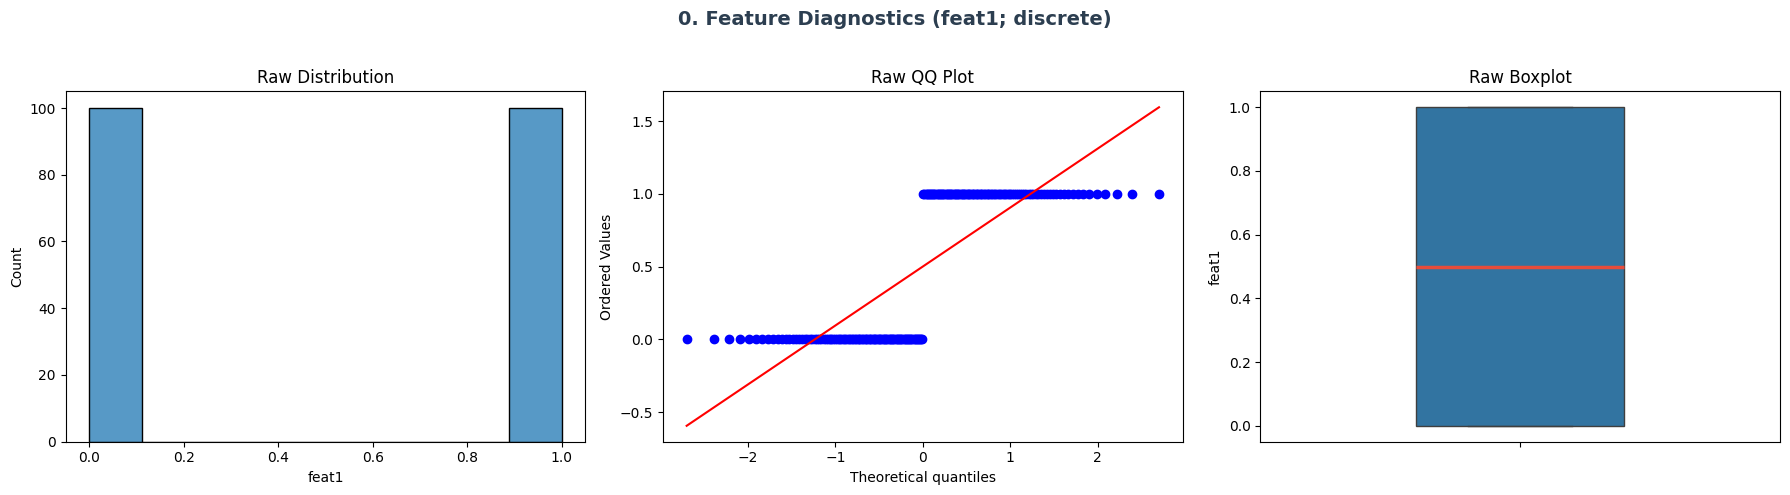

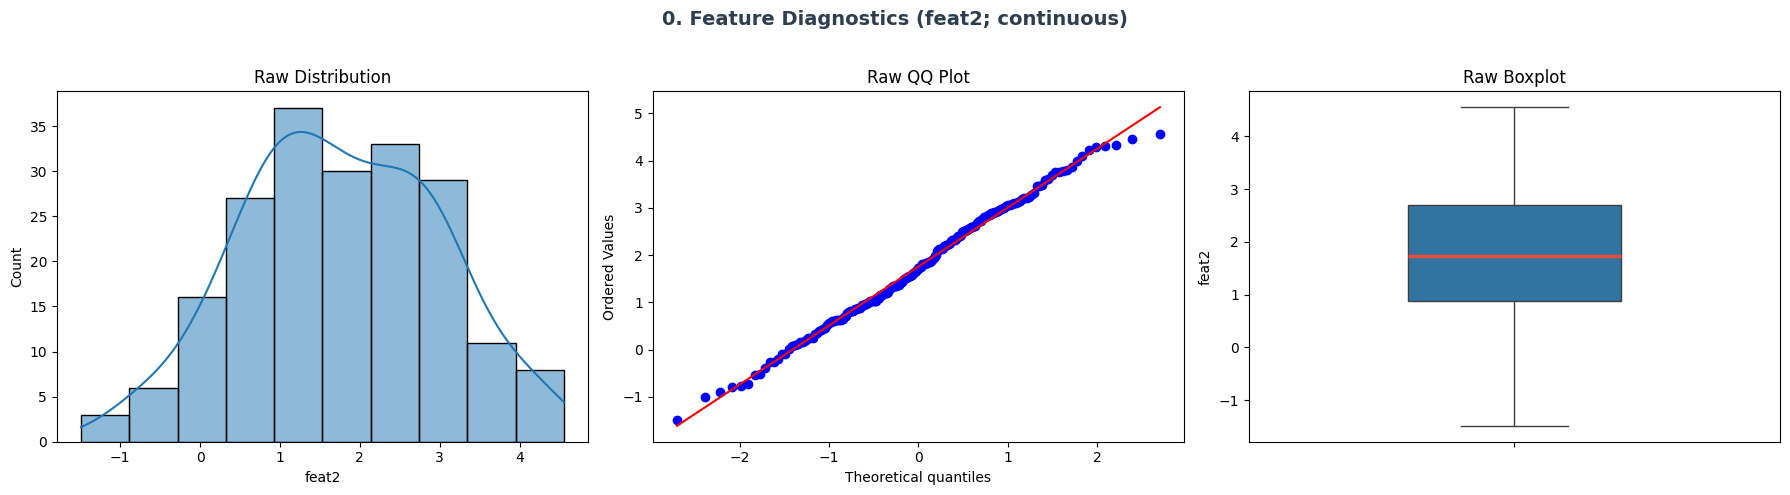

c:\Users\uradz\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


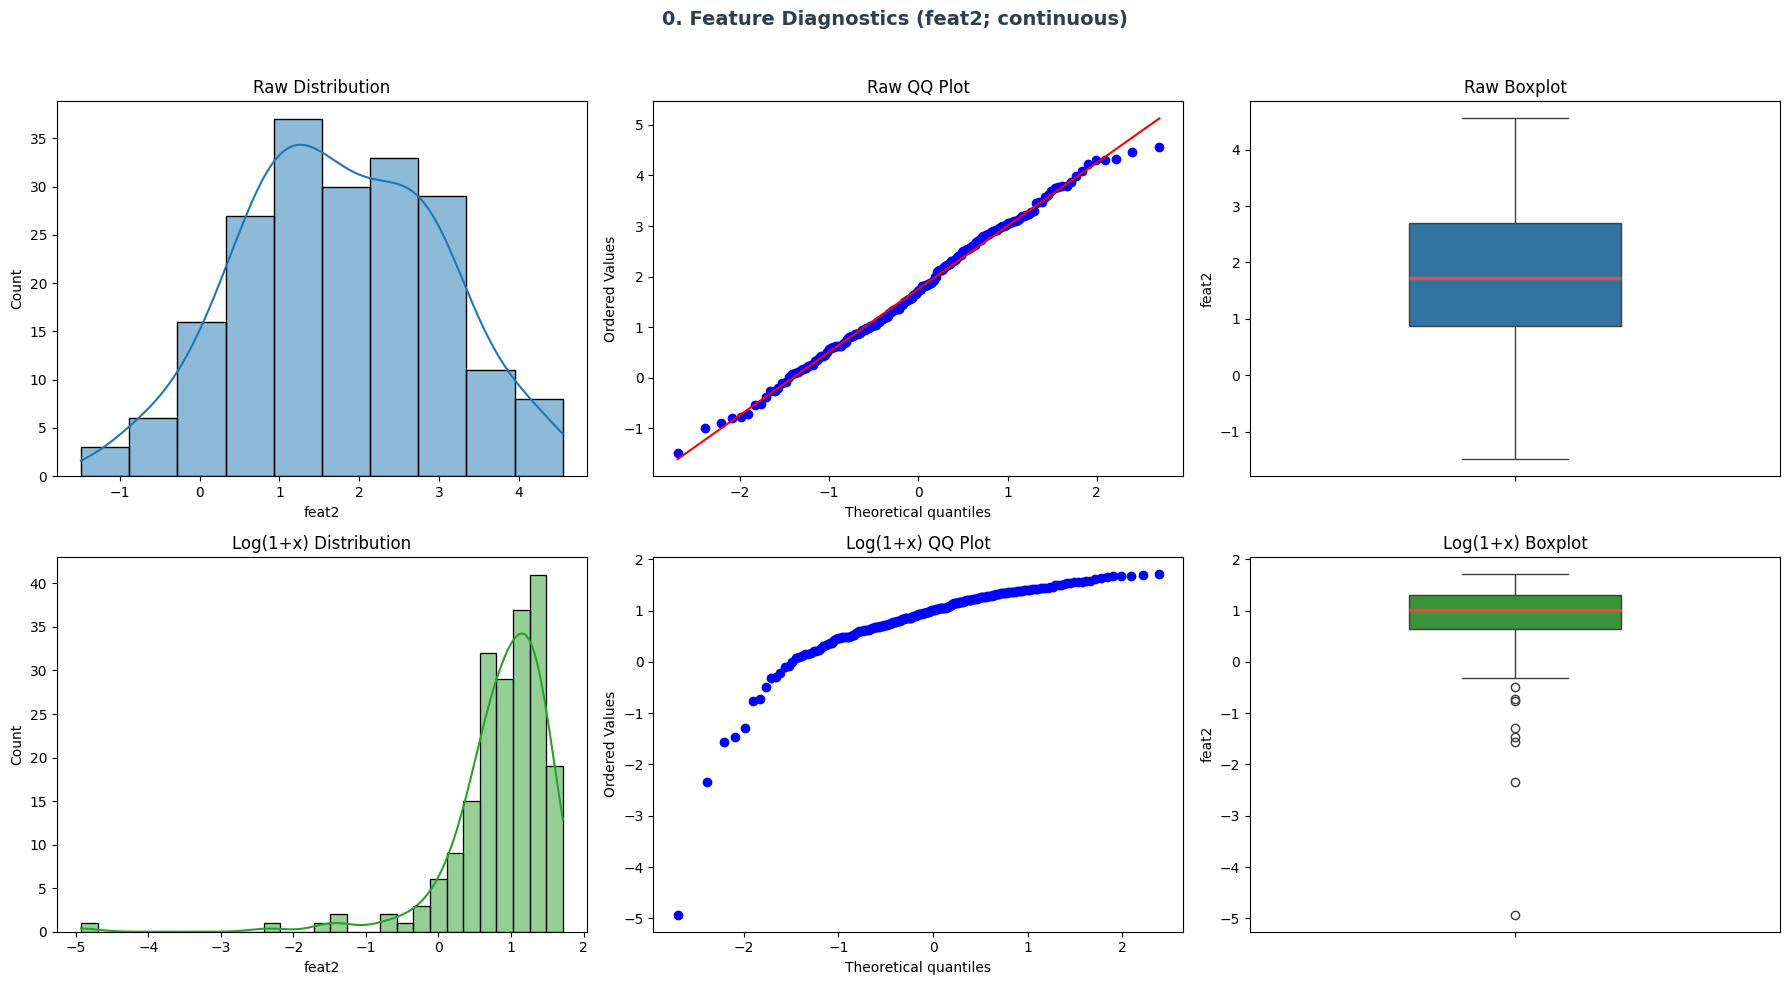

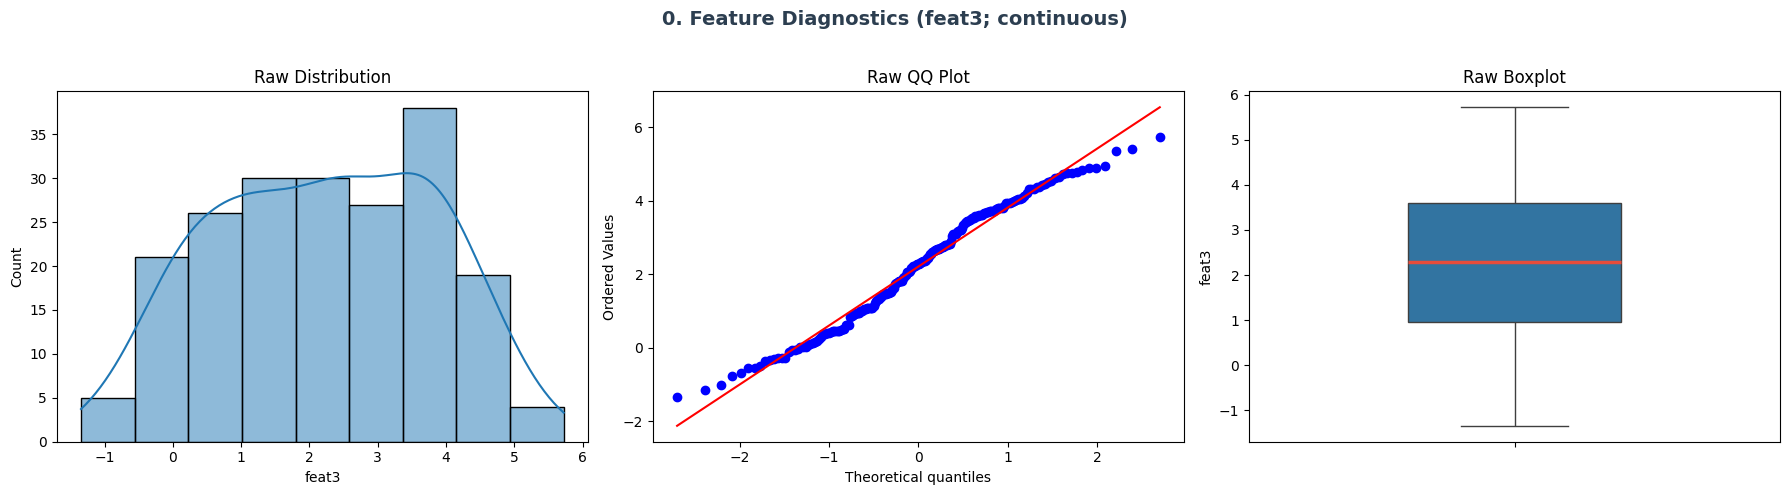

c:\Users\uradz\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


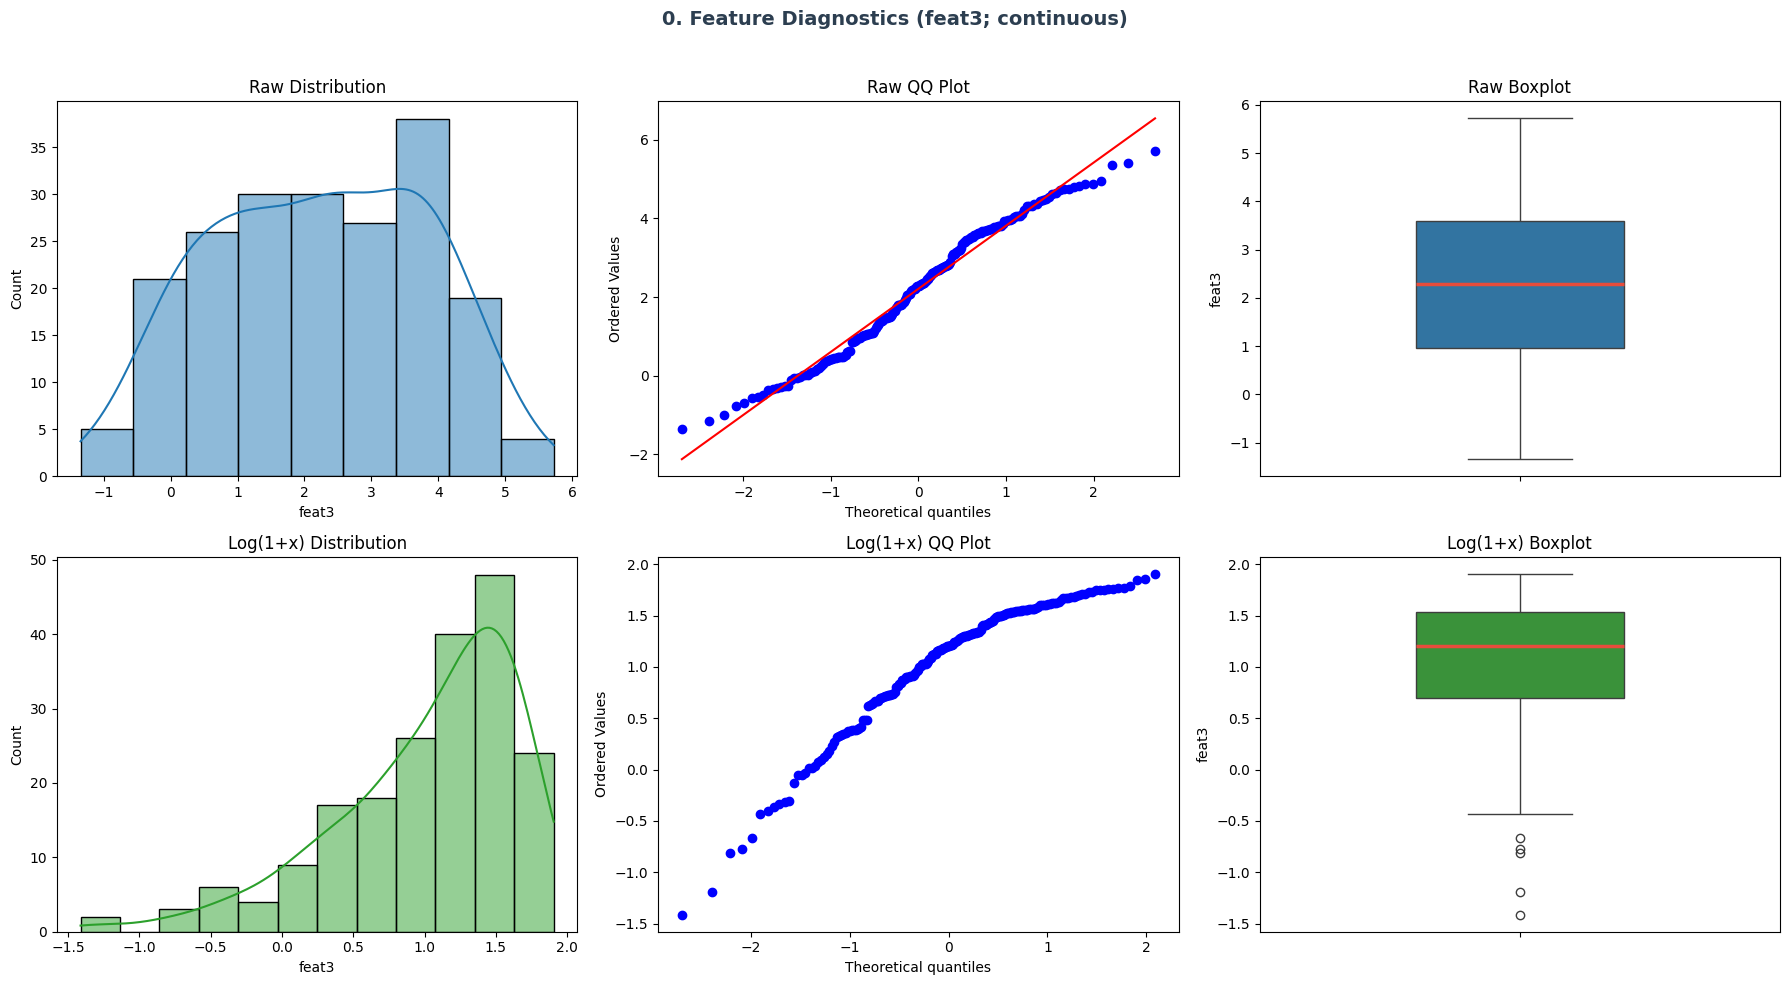

In [8]:
for feat in df_raw.columns:
    # Raw only
    plot_feature_diagnostics(df_raw, [feat])

    # if not a discrete feature
    if feat != 'feat1':
    # With a log transform comparison row
        plot_feature_diagnostics(df_raw, [feat], transform=np.log1p, transform_label="Log(1+x)")

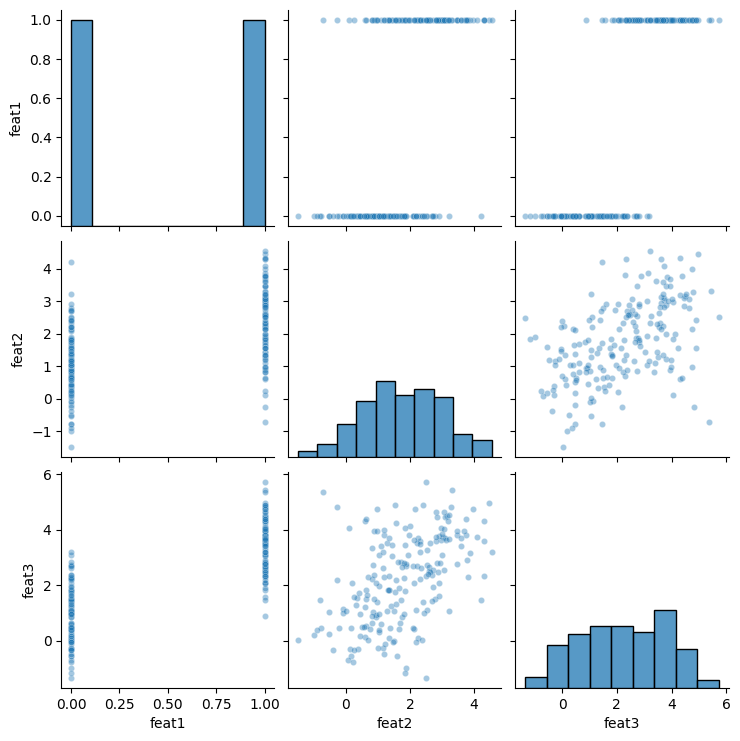

In [9]:
sns.pairplot(df_raw, plot_kws={"s": 20, "alpha": 0.4})
plt.show()

Transformation doesn't help as the data is not skewed. No reason to transform.

#### Summary:
- `feat1` is a discrete variable, perfectly balanced - 100 zeroes and 100 ones. 
- `feat2` is a continuous variable [-1.48, 4.55] +- 1.24; normally distributed
- `feat3` is a continuous variable [-1.34, 5.72] +- 1.6; approaching normal distribution

We might assume `feat1` is actually a cluster label because the task is to use K-means and the mean of discrete variables carries no physical or mathematical meaning. But then, the format of the column is a precise float `0.000000000000000000e+00`, but what's the point of `float` in a discrete variable anyway? The filename is `data_2D.csv` and both `feat2` and `feat3` are on the same scale, so it only makes sense to conclude these two are the only features.

In [10]:
X = df_raw.drop(columns=['feat1'])
X = X.rename(columns={'feat2':'feat1', 'feat3':'feat2'})
X

,feat1,feat2
0,-0.768716,0.460860
1,2.687848,2.366961
2,-0.201379,0.470430
3,0.608496,1.225400
4,-0.082282,1.137218
...,...,...
195,0.629144,4.378584
196,-0.723824,5.361801
197,1.346107,2.333476
198,3.608219,3.411546


### Missing values overview

In [11]:
df_nulls = get_null_info(X)
df_nulls

No missing values are found in the data_frame


""


### Scaling

The algorithm assigns points to clusters purely by Euclidean distance. To make the comparison fair, we need to scale the data.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)    # scale once, reuse across all k
X_scaled[:5]

array([[-2.04352628, -1.09335983],
       [ 0.75105098,  0.09709163],
       [-1.58484322, -1.08738314],
       [-0.93007208, -0.61586796],
       [-1.48855482, -0.67094181]])

### Baseline fit

The Elbow method is often visually ambiguous (usually for large number of clusters). As $k$ increases, inertia always decreases, adding one more cluster reduces inertia meaningfully to the left of it, producing diminishing returns to the right. Which is why a second metric is needed. The **Silhouette score** measures how well each point fits its own cluster versus the next-nearest cluster.

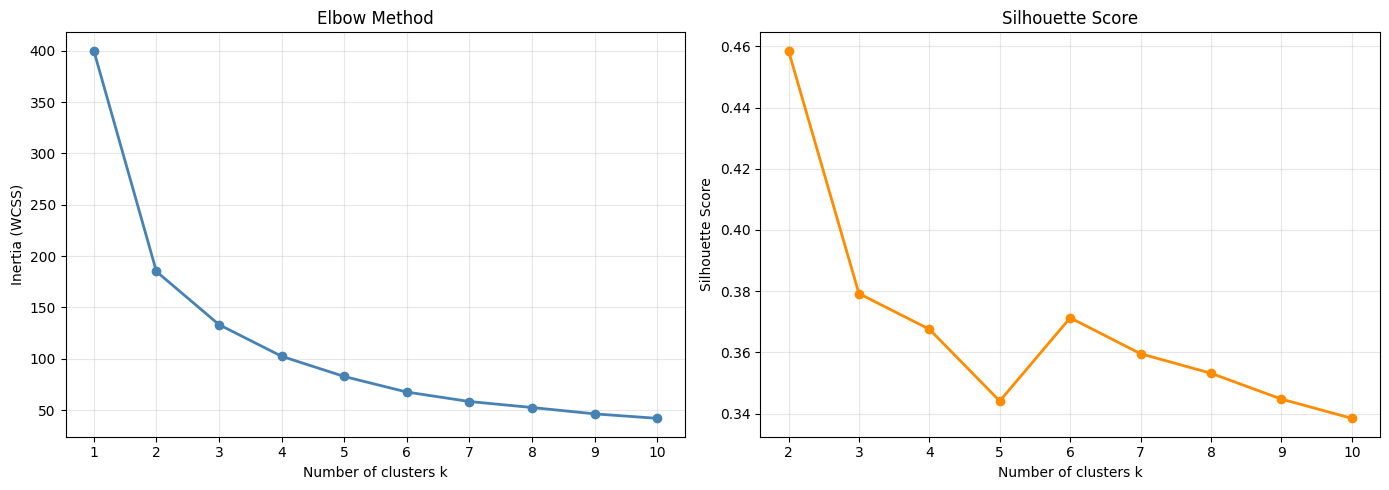

In [13]:
# ----- STEP 1: Fit the model -----
k_range = range(1, 11)                  # presumable number of clusters to try out
inertias = []                           # inertias to accumulate
silhouette_scores = []                  # silhouette scores to accumulate

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',           # smart initialization — industry standard
        n_init=10,                  # run 10 times for current k, return the lowest-inertia result
        max_iter=300,               # fallback convergence cap (to prevent infinite loops on non-converging initializations)
        random_state=RANDOM_SEED,
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    # silhouette undefined for k=1 (only one cluster, no comparison possible)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouette_scores.append(None)

# ----- STEP 2: Plotting -----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Elbow plot ---
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# --- PLOT 2: Silhouette plot ---
valid_k = [k for k in k_range if k >= 2]                                    # exclude k=1 from Silhouette scores
valid_scores = [s for s in silhouette_scores if s is not None]              # exclude k=1 from Silhouette scores
ax2.plot(valid_k, valid_scores, 'o-', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(valid_k)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
silhouette_scores

[None,
 0.45861251323506386,
 0.379208417886842,
 0.3675647597070843,
 0.3440715174016588,
 0.3712873113707966,
 0.3595368231388603,
 0.3531569663600822,
 0.3447115743049035,
 0.33841797860979883]

The file has lived up to its name, there are indeed two different clusters with a more or less ambiguous assignment (silhouette score of ~0.46).

This score becomes our baseline to compare against after outlier detection, this will show the impact of noise:

In [18]:
# ----- Fit final model at chosen k -----
OPTIMAL_K = 2

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=OPTIMAL_K,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=RANDOM_SEED,
    )),
])

final_pipeline.fit(X)
labels = final_pipeline.named_steps['kmeans'].labels_

print(f"Chosen k: {OPTIMAL_K}")
print(f"Final inertia: {final_pipeline.named_steps['kmeans'].inertia_:.4f}")
print(f"Silhouette score: {silhouette_score(final_pipeline.named_steps['scaler'].transform(X), labels):.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True), strict=True))}")

Chosen k: 2
Final inertia: 184.9778
Silhouette score: 0.4586
Cluster sizes: {0: 94, 1: 106}


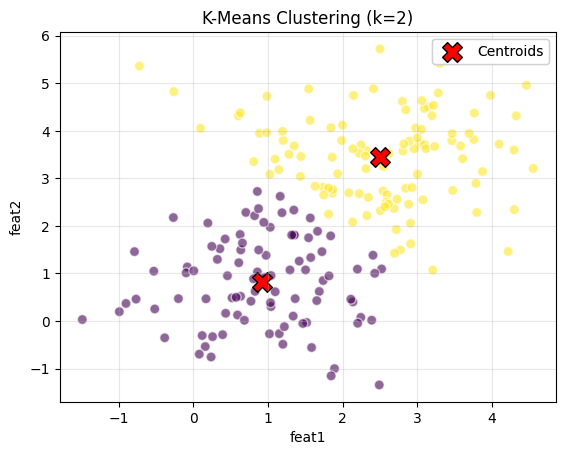

In [19]:
# Visualize the Clusters
final_scaler = final_pipeline.named_steps["scaler"]
final_kmeans = final_pipeline.named_steps["kmeans"]
centers_scaled = final_kmeans.cluster_centers_
centers_original = final_scaler.inverse_transform(centers_scaled)

# Plot the data points colored by cluster label using original scale
scatter = plt.scatter(
    X["feat1"],
    X["feat2"],
    c=labels,
    cmap="viridis",
    alpha=0.6,
    edgecolors="w",
    s=50,
)

# Plot cluster centroids
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids",
    edgecolors="black",
)

plt.xlabel("feat1")
plt.ylabel("feat2")
plt.title(f"K-Means Clustering (k={OPTIMAL_K})")
plt.grid(True, alpha=0.3)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(
    plt.legend([plt.gca().get_legend_handles_labels()[0][0]], ["Centroids"], loc="upper right")
)

plt.show()

Cluster sizes: {0: 94, 1: 106}. Expected: {0: 100, 1: 100}

It isn't reasonable to try and build classification report, it is clustering and we are not supposed to fight for f1 scores here.

### Outlier detection

Scatterplot visual inspection doesn't provide enough insight and is subjective anyway. The variables are distributed normally, so we could use `z-scores` / `gaussian anomaly detection` / `local outlier factor`.
- `z-scores` is univariate and we saw nothing significantly distant in boxplots
- `gaussian anomaly detection` is a good multi- and univariate detector given the variable normality
- `local outlier factor` is a good multivariate one, but our data is normal and forms a single cluster which is more the case for gaussian

Epsilon threshold: 3.949e-03
Anomalies flagged: 4


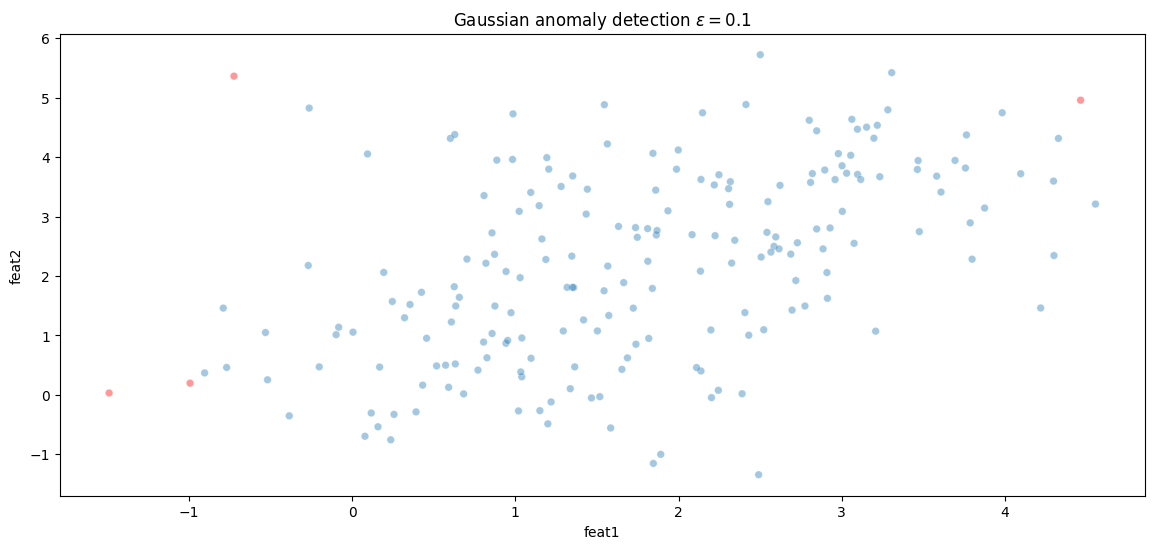

In [ ]:
# ----- STEP 1: Fit a Gaussian per feature (mean + std) -----
params = {}
for feat in X.columns:
    params[feat] = (X[feat].mean(), X[feat].std())

# ----- STEP 2: Compute total probability per row (product of per-feature densities) -----
def gaussian_prob(X, params):
    probs = np.ones(len(X))
    for feat, (mu, sigma) in params.items():
        probs *= norm.pdf(X[feat], loc=mu, scale=sigma)
    return probs

probs = gaussian_prob(X, params)

# ----- STEP 3: Choose epsilon threshold -----
# lower epsilon = fewer flagged.
epsilon = np.percentile(probs, 2)  # flag bottom 2% as anomalies
print(f"Epsilon threshold: {epsilon:.3e}")

# ----- STEP 4: Flag anomalies (probability below epsilon) -----
anomaly_mask = probs < epsilon
print(f"Anomalies flagged: {anomaly_mask.sum()}")

# ----- STEP 5: Inspect to tune -----
fig, ax = plt.subplots(figsize=(14,6), ncols=1, nrows=1)
plot_scatter(X, 'feat1', 'feat2', ax, anomaly_mask, regline=False, title="Gaussian anomaly detection $\epsilon=0.2$")

# ----- STEP 6: Drop the outliers -----
X_clean = X[~anomaly_mask].copy()

Given that we possess true cluster labels, we could tune the detector to be more precise (for using it on unseen data in the future), but the task assumes explaining the data, so we pretend we don't have the labels. And it also doesn't make sense to tune based on Silhouette score as lowering the threshold will almost always artificially inflate your silhouette score.

In [21]:
# ----- Fit final model at chosen k -----
OPTIMAL_K = 2

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=OPTIMAL_K,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=RANDOM_SEED,
    )),
])

final_pipeline.fit(X_clean)
labels = final_pipeline.named_steps['kmeans'].labels_

print(f"Chosen k: {OPTIMAL_K}")
print(f"Final inertia: {final_pipeline.named_steps['kmeans'].inertia_:.4f}")
print(f"Silhouette score: {silhouette_score(final_pipeline.named_steps['scaler'].transform(X_clean), labels):.4f}")
print(f"Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True), strict=True))}")

Chosen k: 2
Final inertia: 178.2418
Silhouette score: 0.4611
Cluster sizes: {0: 92, 1: 104}


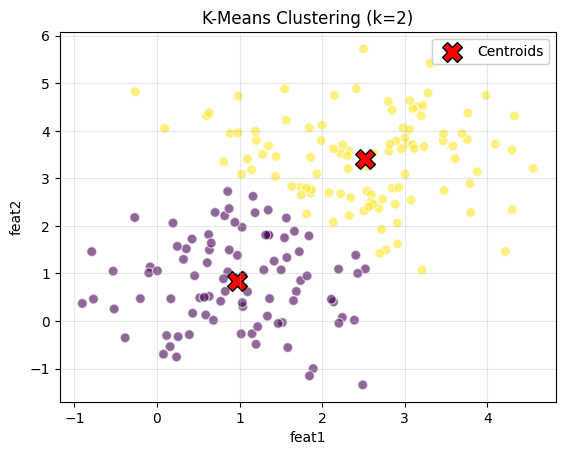

In [22]:
# Visualize the Clusters
final_scaler = final_pipeline.named_steps["scaler"]
final_kmeans = final_pipeline.named_steps["kmeans"]
centers_scaled = final_kmeans.cluster_centers_
centers_original = final_scaler.inverse_transform(centers_scaled)

# Plot the data points colored by cluster label using original scale
scatter = plt.scatter(
    X_clean["feat1"],
    X_clean["feat2"],
    c=labels,
    cmap="viridis",
    alpha=0.6,
    edgecolors="w",
    s=50,
)

# Plot cluster centroids
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids",
    edgecolors="black",
)

plt.xlabel("feat1")
plt.ylabel("feat2")
plt.title(f"K-Means Clustering (k={OPTIMAL_K})")
plt.grid(True, alpha=0.3)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(plt.legend([plt.gca().get_legend_handles_labels()[0][0]], ["Centroids"], loc="upper right"))

plt.show()

Silhouette scores and metrics have improved.

### Conclusion

Each cluster tendencies are tend to be:

In [23]:
# ----- 1. Map the Cluster Labels Back to X_clean -----
X_clean["Cluster"] = labels

# ----- 2. Run Group Profiling Aggregations -----
print("=== CLUSTER PROFILES ===")
cluster_profiles = X_clean.groupby("Cluster").agg(
    {
        "feat1": ["count", "mean", "std"],
        "feat2": ["mean", "std"],
    },
)
cluster_profiles

=== CLUSTER PROFILES ===


feat1                         feat2          
        count      mean       std      mean       std
Cluster                                              
0          92  0.964488  0.798443  0.840609  0.924113
1         104  2.517174  0.977933  3.407867  0.919027